<a href="https://colab.research.google.com/github/Slushi3/Fly_Dino/blob/main/Fly_Dino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install pyarrow imageio

In [2]:
from google.colab import auth
auth.authenticate_user()

B = "gs://flyem-male-cns/v1.0/connectome-data/flat-connectome"
!mkdir -p malecns
!gsutil -m cp {B}/connectome-weights-male-cns-v1.0-minconf-0.5.feather \
              {B}/body-annotations-male-cns-v1.0-minconf-0.5.feather \
              {B}/body-neurotransmitters-male-cns-v1.0.feather malecns/
!ls -lh malecns

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://flyem-male-cns/v1.0/connectome-data/flat-connectome/connectome-weights-male-cns-v1.0-minconf-0.5.feather...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

Copying gs://flyem-male-cns/v1.0/connectome-data/flat-connectome/body-annotations-male-cns-v1.0-minconf-0.5.feather...
Copying gs://flyem-male-cns/v1.0/connectome-data/flat-connectome/body-neurotransmitters-male-cns-v1.0.feather...
| [3/3 files][  1.0 GiB/  1.0 GiB] 100% Done  66.9 MiB/s ETA 00:00:00           
Operation completed over 3 objects/1.0 GiB.                   

In [4]:
import pandas as pd, numpy as np, gc
import pyarrow.feather as feather, pyarrow.compute as pc

P = "malecns/"
# memory_map=True means the big table isn't fully loaded into RAM
tW  = feather.read_table(P + "connectome-weights-male-cns-v1.0-minconf-0.5.feather", memory_map=True)
ann = pd.read_feather(P + "body-annotations-male-cns-v1.0-minconf-0.5.feather")
nt  = pd.read_feather(P + "body-neurotransmitters-male-cns-v1.0.feather")
print("W rows:", tW.num_rows, "cols:", tW.schema.names)
print("ann cols:", list(ann.columns)); print("nt cols:", list(nt.columns))

def pick(names, *cands):
    for c in cands:
        if c in names: return c
    raise KeyError(f"none of {cands} found in {list(names)}")

pre_c  = pick(tW.schema.names, "body_pre", "bodyId_pre", "pre")
post_c = pick(tW.schema.names, "body_post", "bodyId_post", "post")
w_c    = pick(tW.schema.names, "weight", "count", "total_weight")
ann_id = pick(ann.columns, "bodyId", "body", "body_id")
type_c = pick(ann.columns, "type", "cell_type")
nt_id  = pick(nt.columns, "bodyId", "body", "body_id")
nt_c   = [c for c in nt.columns if c != nt_id and nt[c].dtype == object][0]
print("NT column:", nt_c, nt[nt_c].value_counts().head(8).to_dict())

# Keep only strong edges, as compact arrays
MIN_W = 10
tf = tW.select([pre_c, post_c, w_c]).filter(pc.greater_equal(tW[w_c], MIN_W))
src = tf[pre_c].to_numpy().astype(np.int64)
dst = tf[post_c].to_numpy().astype(np.int64)
wt  = tf[w_c].to_numpy().astype(np.float32)
del tW, tf; gc.collect()
print("edges kept:", len(src))

W rows: 151856684 cols: ['body_pre', 'body_post', 'weight']
ann cols: ['assignedOlHex1', 'assignedOlHex2', 'bodyId', 'flywireType', 'group', 'instance', 'somaSide', 'statusLabel', 'superclass', 'type', 'vfbId', 'hemibrainType', 'itoleeHl', 'supertype', 'birthtime', 'mancBodyid', 'mancGroup', 'mancType', 'subclass', 'synonyms', 'class', 'rootSide', 'somaNeuromere', 'trumanHl', 'dimorphism', 'matchingNotes', 'entryNerve', 'mancSerial', 'mcnsSerial', 'serialMotif', 'fruDsx', 'exitNerve', 'receptorType', 'somaLocation', 'tosomaLocation', 'status']
nt cols: ['body', 'cell_type', 'total_nt_predictions', 'predicted_nt_confidence', 'predicted_nt', 'ground_truth', 'celltype_total_nt_predictions', 'celltype_predicted_nt', 'celltype_predicted_nt_confidence', 'consensus_nt']
NT column: cell_type {'R1-R6': 3377, 'Tm3': 2054, 'T3': 1940, 'T2a': 1871, 'L5': 1787, 'L2': 1779, 'C3': 1779, 'T4c': 1778}
edges kept: 2799910


In [5]:
t = ann[type_c].astype(str)
sens = ann.loc[t.str.contains("LPLC2|LC4", regex=True), ann_id].values
out  = ann.loc[t.str.contains("DNp01", regex=True), ann_id].values
print(len(sens), "looming neurons;", len(out), "output neurons")
if len(out) == 0:
    print("Try one of these:", sorted(t[t.str.startswith("DN")].unique())[:40])

484 looming neurons; 2 output neurons


In [6]:
import scipy.sparse as sp
HOPS = 3

def reach(seed, forward, hops):
    seen = np.unique(seed.astype(np.int64)); frontier = seen
    a, b = (src, dst) if forward else (dst, src)
    for _ in range(hops):
        nxt = np.unique(b[np.isin(a, frontier)])
        new = np.setdiff1d(nxt, seen)
        if len(new) == 0: break
        seen = np.union1d(seen, new); frontier = new
    return seen

fwd = reach(sens, True, HOPS)
bwd = reach(out, False, HOPS)
ids = np.union1d(np.intersect1d(fwd, bwd), np.union1d(sens, out)).astype(np.int64)
print("subgraph neurons:", len(ids))

m = np.isin(src, ids) & np.isin(dst, ids)
s_i = np.searchsorted(ids, src[m]); d_i = np.searchsorted(ids, dst[m]); w_s = wt[m]
print("subgraph edges:", m.sum())
del src, dst, wt; gc.collect()          # free the big arrays

lab = nt.set_index(nt_id)[nt_c].astype(str).str.lower()
sign = np.array([-1.0 if any(k in lab.get(int(b), "") for k in ("gaba", "glut")) else 1.0
                 for b in ids], dtype=np.float32)

n = len(ids)
M = sp.csr_matrix((w_s * sign[s_i], (d_i, s_i)), shape=(n, n))
rowsum = np.asarray(abs(M).sum(1)).ravel(); rowsum[rowsum == 0] = 1
Wm = (sp.diags(1 / rowsum) @ M).tocsr()

sens_i = np.searchsorted(ids, np.intersect1d(sens, ids))
out_i  = np.searchsorted(ids, np.intersect1d(out, ids))
print("sensory:", len(sens_i), "output:", len(out_i))

subgraph neurons: 73611
subgraph edges: 1610924
sensory: 484 output: 2


In [7]:
class FlyBrain:
    def __init__(self, g=2.0, ext=1.0, decay=0.9, thr=1.0, steps=20, seed=0):
        self.g, self.ext, self.decay, self.thr, self.steps = g, ext, decay, thr, steps
        self.rng = np.random.default_rng(seed)

    def looming_rate(self, dist):
        # 0 when the obstacle is far, rising to ~0.6 spikes/step when close
        return 0.6 * np.clip(1 - dist / 250, 0, 1) ** 2

    def run(self, dist):
        n = Wm.shape[0]; v = np.zeros(n); out_spikes = 0
        p = self.looming_rate(dist)
        for _ in range(self.steps):
            ext = np.zeros(n)
            ext[sens_i] = (self.rng.random(len(sens_i)) < p) * self.ext
            spk = v > self.thr
            v = v * self.decay + self.g * (Wm @ spk.astype(float)) + ext
            v[spk] = 0
            out_spikes += (v[out_i] > self.thr).sum()
        return out_spikes

In [8]:
def prob_fire(brain, dist, trials=10):
    return np.mean([brain.run(dist) >= 1 for _ in range(trials)])

best = None
for g in [1, 2, 4, 8]:
    for ext in [0.3, 0.6, 1.0, 2.0]:
        b = FlyBrain(g=g, ext=ext)
        near, far = prob_fire(b, 100), prob_fire(b, 250)
        print(f"g={g} ext={ext}  near={near:.1f} far={far:.1f}")
        if near >= 0.8 and far <= 0.1 and best is None:
            best = (g, ext)
print("best:", best)

g=1 ext=0.3  near=0.0 far=0.0
g=1 ext=0.6  near=0.0 far=0.0
g=1 ext=1.0  near=0.0 far=0.0
g=1 ext=2.0  near=0.0 far=0.0
g=2 ext=0.3  near=0.0 far=0.0
g=2 ext=0.6  near=0.0 far=0.0
g=2 ext=1.0  near=0.0 far=0.0
g=2 ext=2.0  near=0.6 far=0.0
g=4 ext=0.3  near=0.0 far=0.0
g=4 ext=0.6  near=1.0 far=0.0
g=4 ext=1.0  near=1.0 far=0.0
g=4 ext=2.0  near=1.0 far=0.0
g=8 ext=0.3  near=0.9 far=0.0
g=8 ext=0.6  near=1.0 far=0.0
g=8 ext=1.0  near=1.0 far=0.0
g=8 ext=2.0  near=1.0 far=0.0
best: (4, 0.6)


frame 14: JUMP at dist=98
frame 52: JUMP at dist=102
frame 98: JUMP at dist=109
frame 132: JUMP at dist=103
frame 179: JUMP at dist=106
frame 217: JUMP at dist=105
frame 255: JUMP at dist=109
frame 302: JUMP at dist=105
frame 342: JUMP at dist=106
frame 384: JUMP at dist=108
frame 427: JUMP at dist=102
frame 475: JUMP at dist=103
frame 523: JUMP at dist=106
frame 569: JUMP at dist=98
frame 602: JUMP at dist=102
frame 649: JUMP at dist=99
frame 687: JUMP at dist=104
frame 726: JUMP at dist=103
frame 766: JUMP at dist=99
frame 803: JUMP at dist=106
frame 850: JUMP at dist=106
frame 891: JUMP at dist=105
frame 932: JUMP at dist=105
frame 971: JUMP at dist=104
frame 1008: JUMP at dist=103
frame 1042: JUMP at dist=108
frame 1091: JUMP at dist=109
frame 1124: JUMP at dist=107
frame 1163: JUMP at dist=100
frame 1210: JUMP at dist=115
frame 1253: JUMP at dist=101
frame 1300: JUMP at dist=108
frame 1347: JUMP at dist=109
frame 1383: JUMP at dist=108
frame 1432: JUMP at dist=104
frame 1478: JUMP

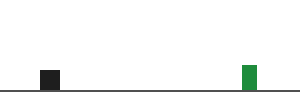

In [13]:
import imageio, random
from IPython.display import Image, display

def play(brain, max_frames=1500, record=True, gap=(260, 400), verbose=True):
    dino_x, y, vy = 40, 0.0, 0.0
    speed, obst, frames, cleared = 8, [250], [], 0
    for f in range(max_frames):
        ahead = [o for o in obst if o + 15 > dino_x]
        dist = (min(ahead) - dino_x) if ahead else 999
        if y == 0 and brain.run(dist) >= 1:
            vy = 12.0
            if verbose: print(f"frame {f}: JUMP at dist={dist:.0f}")
        y = max(0.0, y + vy); vy -= 0.9
        if y == 0: vy = 0
        new = [o - speed for o in obst]
        cleared += sum(1 for o in new if o <= -20)
        obst = [o for o in new if o > -20]
        if max(obst) < 300: obst.append(max(obst) + random.randint(*gap))
        if any(dino_x < o + 15 and dino_x + 20 > o and y < 25 for o in obst):
            if verbose: print(f"frame {f}: DIED, y={y:.0f}, dist={dist:.0f}")
            break
        if record and f % 2 == 0:
            img = np.full((100, 300, 3), 255, np.uint8)
            img[90:92] = 80
            yy = int(90 - 20 - y); img[max(yy, 0):yy + 20, dino_x:dino_x + 20] = (30, 30, 30)
            for o in obst:
                if 0 <= o < 285: img[65:90, int(o):int(o) + 15] = (30, 140, 60)
            frames.append(img)
    return cleared, frames, f

brain = FlyBrain(g=g, ext=ext)
cleared, frames, last = play(brain)
print("cleared:", cleared, "| survived frames:", last)
imageio.mimsave("fly_dino.gif", frames, duration=0.04)
display(Image("fly_dino.gif"))

In [12]:
b = FlyBrain(g=g, ext=ext)
for d in range(300, 0, -20):
    print(f"dist={d:3d}  P(fire)={prob_fire(b, d, trials=20):.2f}")

dist=300  P(fire)=0.00
dist=280  P(fire)=0.00
dist=260  P(fire)=0.00
dist=240  P(fire)=0.00
dist=220  P(fire)=0.00
dist=200  P(fire)=0.00
dist=180  P(fire)=0.00
dist=160  P(fire)=0.00
dist=140  P(fire)=0.00
dist=120  P(fire)=0.00
dist=100  P(fire)=1.00
dist= 80  P(fire)=1.00
dist= 60  P(fire)=1.00
dist= 40  P(fire)=1.00
dist= 20  P(fire)=1.00


cleared: 15 | score: 349


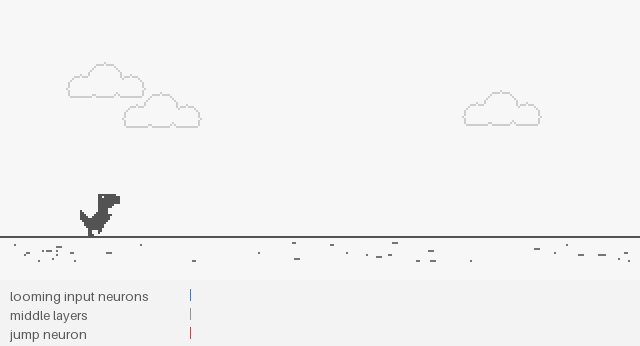

In [19]:
import numpy as np, random, imageio
from PIL import Image as PILImage, ImageDraw, ImageFont
from IPython.display import Image, display

BG, FG, GREY, CLOUD = (247,247,247), (83,83,83), (117,117,117), (205,205,205)
W, H, GROUND, S, DINO_X = 320, 140, 118, 2, 40      # logical size; drawn at 2x

def bm(rows):
    w = max(len(r) for r in rows)
    return np.array([[c == '#' for c in r.ljust(w, '.')] for r in rows])

# ---------- sprites ----------
BODY = [
".........#########..",
".........##.########",
".........###########",
".........###########",
".........###########",
".........########...",
".........#######....",
".........#####......",
"#........#####......",
"##......######......",
"###....#########....",
"####..#########.....",
"###############.....",
".#############......",
"..###########.......",
"..##########........",
"...#########........",
"....#######.........",
]
LEG_A = ["....##...##.........", "....##...#..........", "....###............."]
LEG_B = ["....##...##.........", "....#....##.........", ".........###........"]
DINO_A, DINO_B = bm(BODY + LEG_A), bm(BODY + LEG_B)

def make_cactus(h, tw, left, right):
    w, t0 = tw + 8, 4
    a = np.zeros((h, w), bool)
    a[:, t0:t0+tw] = True
    a[0, t0] = a[0, t0+tw-1] = False                 # rounded top
    if left:
        r = int(h * .5)
        a[r:r+3, 0:t0+1] = True; a[max(r-7, 0):r+3, 0:2] = True
    if right:
        r = int(h * .32)
        a[r:r+3, t0+tw-1:w] = True; a[max(r-6, 0):r+3, w-2:w] = True
    return a

def make_cluster(rng):
    parts = []
    for _ in range(rng.choice([1, 1, 2, 3])):
        if rng.random() < .5: parts.append(make_cactus(18, 3, rng.random() < .5, False))
        else:                 parts.append(make_cactus(28, 4, True, True))
    hh = max(p.shape[0] for p in parts); cols = []
    for p in parts:
        pad = np.zeros((hh, p.shape[1]), bool); pad[hh - p.shape[0]:] = p
        cols += [pad, np.zeros((hh, 2), bool)]
    return np.hstack(cols[:-1])

def make_cloud():
    yy, xx = np.mgrid[0:22, 0:48]; m = np.zeros((22, 48), bool)
    for cx, cy, r in [(10, 13, 7), (22, 9, 9), (35, 13, 7)]:
        m |= (xx - cx)**2 + (yy - cy)**2 <= r * r
    m[18:] = False
    inner = np.zeros_like(m)
    inner[1:-1, 1:-1] = m[1:-1, 1:-1] & m[:-2, 1:-1] & m[2:, 1:-1] & m[1:-1, :-2] & m[1:-1, 2:]
    return m & ~inner
CLOUD_SP = make_cloud()

# ---------- pixel font for the score ----------
GLYPH = {c: bm(g.split()) for c, g in {
 '0':"111 101 101 101 111", '1':"010 110 010 010 111", '2':"111 001 111 100 111",
 '3':"111 001 111 001 111", '4':"101 101 111 001 001", '5':"111 100 111 001 111",
 '6':"111 100 111 101 111", '7':"111 001 001 001 001", '8':"111 101 111 101 111",
 '9':"111 101 111 001 111", 'H':"101 101 111 101 101", 'I':"111 010 010 010 111"}.items()}

def blit(img, sp, x, y, color):
    h, w = sp.shape; x0, y0 = int(x), int(y)
    xs, ys = max(x0, 0), max(y0, 0)
    xe, ye = min(x0 + w, img.shape[1]), min(y0 + h, img.shape[0])
    if xs >= xe or ys >= ye: return
    img[ys:ye, xs:xe][sp[ys - y0:ye - y0, xs - x0:xe - x0]] = color

def text(img, s, x, y, color, k=2):
    for ch in s:
        blit(img, np.kron(GLYPH[ch], np.ones((k, k))).astype(bool), x, y, color); x += 4 * k

_gr = random.Random(3)
BUMPS = [(_gr.randint(0, 639), _gr.randint(3, 12), _gr.choice([1, 1, 2, 3])) for _ in range(70)]

try:    FONT_UI, FONT_BIG = ImageFont.load_default(size=13), ImageFont.load_default(size=22)
except TypeError: FONT_UI = FONT_BIG = ImageFont.load_default()

# ---------- drawing ----------
def render(y, obst, clouds, scroll, f, score, hi):
    img = np.empty((H, W, 3), np.uint8); img[:] = BG
    for cx, cy in clouds: blit(img, CLOUD_SP, cx, cy, CLOUD)
    img[GROUND, :] = FG
    for bx, by, bl in BUMPS:
        x = (bx - scroll) % 640
        if x < W: img[GROUND + by, x:min(x + bl, W)] = GREY
    for o in obst: blit(img, o[1], o[0], GROUND - o[1].shape[0], FG)
    sp = DINO_A if (y > 0 or (f // 3) % 2 == 0) else DINO_B
    blit(img, sp, DINO_X, GROUND - sp.shape[0] - y, FG)
    text(img, "HI", W - 124, 8, GREY); text(img, f"{hi:05d}", W - 100, 8, GREY)
    text(img, f"{score:05d}", W - 48, 8, FG)
    return img.repeat(S, 0).repeat(S, 1)

def brain_panel(act, width):
    p = PILImage.new("RGB", (width, 66), (243, 243, 243)); d = ImageDraw.Draw(p)
    items = [("looming input neurons", (60, 120, 220)), ("middle layers", (150, 150, 150)),
             ("jump neuron", (220, 60, 60))]
    for k, ((lab, col), a) in enumerate(zip(items, act)):
        y = 8 + k * 19
        d.text((10, y), lab, fill=(90, 90, 90), font=FONT_UI)
        d.rectangle([190, y + 1, 190 + int((width - 210) * min(a * 4, 1)), y + 12], fill=col)
    return np.array(p)

# ---------- the game, driven by the fly brain ----------
def play_pretty(brain, max_frames=700, hi=0, seed=None):
    rng = random.Random(seed)
    layers = [depth == 0, (depth >= 1) & (depth < 99), np.isin(np.arange(len(ids)), out_i)]
    sizes = [max(int(l.sum()), 1) for l in layers]
    y, vy, speed, scroll, cleared = 0.0, 0.0, 8, 0, 0
    obst = [[400, make_cluster(rng), False]]
    clouds = [[rng.randint(0, W), rng.randint(15, 60)] for _ in range(3)]
    frames = []
    for f in range(max_frames):
        ahead = [o for o in obst if o[0] + o[1].shape[1] > DINO_X]
        dist = min(o[0] for o in ahead) - DINO_X if ahead else 999
        rec = run_trace(brain, dist)
        act = [rec[:, l].any(0).sum() / s for l, s in zip(layers, sizes)]
        if y == 0 and rec[:, out_i].any(): vy = 12.0            # the fly decides to jump
        y = max(0.0, y + vy); vy -= 0.9
        if y == 0: vy = 0
        for o in obst:
            o[0] -= speed
            if not o[2] and o[0] + o[1].shape[1] < DINO_X: o[2] = True; cleared += 1
        obst = [o for o in obst if o[0] + o[1].shape[1] > -10]
        if max(o[0] for o in obst) < W + 40:
            obst.append([max(o[0] for o in obst) + rng.randint(260, 400), make_cluster(rng), False])
        for c in clouds:
            c[0] -= speed * .15
            if c[0] < -50: c[0], c[1] = W + rng.randint(0, 80), rng.randint(15, 60)
        scroll += speed
        dead = any(DINO_X + 1 < o[0] + o[1].shape[1] and DINO_X + 19 > o[0] and y < o[1].shape[0] - 2
                   for o in obst)
        game = render(int(y), obst, clouds, scroll, f, f // 2, hi)
        frame = np.vstack([game, brain_panel(act, game.shape[1])])
        if dead:
            im = PILImage.fromarray(frame); d = ImageDraw.Draw(im); s = "G A M E   O V E R"
            d.text(((im.width - d.textlength(s, font=FONT_BIG)) / 2, 90), s, fill=FG, font=FONT_BIG)
            frames += [np.array(im)] * 25
            break
        frames.append(frame)
    return cleared, frames, f // 2

brain = FlyBrain(g=g, ext=ext)
cleared, frames, score = play_pretty(brain, hi=0, seed=1)
print("cleared:", cleared, "| score:", score)
imageio.mimsave("fly_dino_pretty.gif", frames[::2], duration=0.05, loop=0)
display(Image("fly_dino_pretty.gif"))

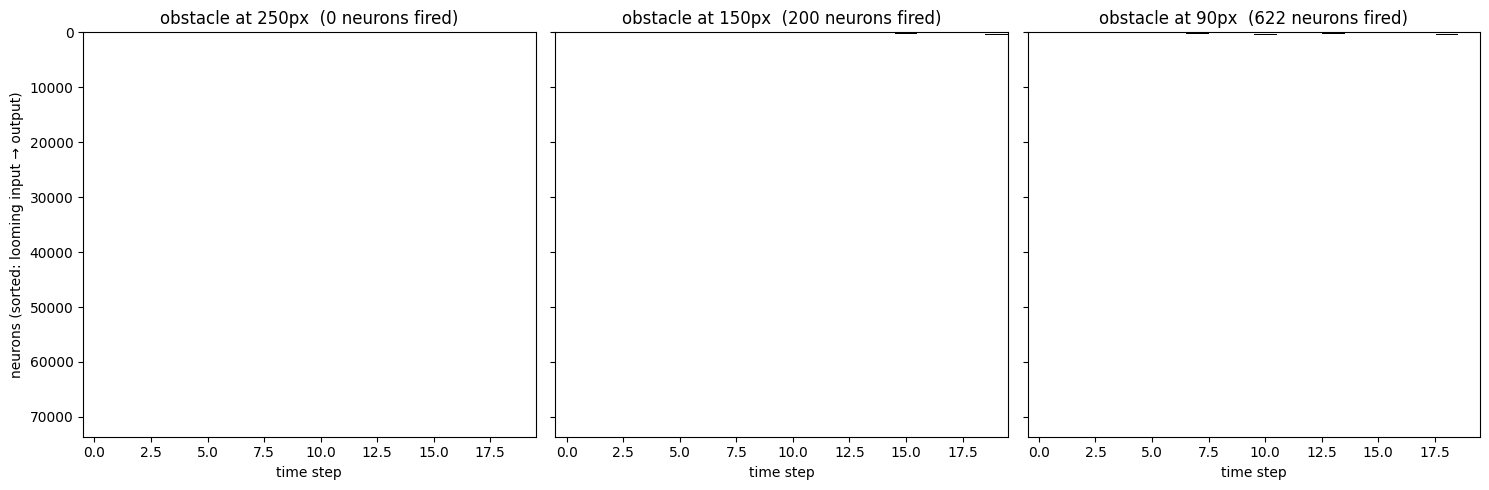

type
LPLC2        177
LC4          113
LPLC4         91
LC40          33
None          14
LC41          13
LC43          13
LC46b         10
PLP172         9
PVLP111        9
PLP009         5
AMMC-A1        5
PLP241         5
LHPV2e1_a      4
LC44           4
Name: count, dtype: int64
output neuron fired: True


In [20]:
import matplotlib.pyplot as plt, scipy.sparse as sp

def run_trace(brain, dist, W=None):
    W = Wm if W is None else W
    n = W.shape[0]; v = np.zeros(n); rec = []
    p = brain.looming_rate(dist)
    for _ in range(brain.steps):
        ext = np.zeros(n)
        ext[sens_i] = (brain.rng.random(len(sens_i)) < p) * brain.ext
        spk = v > brain.thr
        v = v * brain.decay + brain.g * (W @ spk.astype(float)) + ext
        v[spk] = 0
        rec.append(v > brain.thr)
    return np.array(rec)                      # (time, neurons)

# depth = number of synaptic hops from the looming neurons
depth = np.full(len(ids), 99); depth[sens_i] = 0
frontier = sens_i
for d in range(1, 12):
    nxt = np.unique(Wm[:, frontier].nonzero()[0])
    nxt = nxt[depth[nxt] == 99]
    if len(nxt) == 0: break
    depth[nxt] = d; frontier = nxt
order = np.argsort(depth, kind="stable")

brain = FlyBrain(g=g, ext=ext)
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, d in zip(axs, [250, 150, 90]):
    rec = run_trace(brain, d)
    ax.imshow(rec[:, order].T, aspect="auto", cmap="Greys", interpolation="nearest")
    ax.set_title(f"obstacle at {d}px  ({int(rec.any(0).sum())} neurons fired)")
    ax.set_xlabel("time step")
axs[0].set_ylabel("neurons (sorted: looming input → output)")
plt.tight_layout(); plt.show()

# which real cell types fired when the obstacle was close?
rec = run_trace(brain, 90)
fired = ids[rec.any(0)]
tt = ann[ann[ann_id].isin(fired)][type_c].astype(str).value_counts()
print(tt.head(15))
print("output neuron fired:", rec[:, out_i].any())

In [15]:
def fire_prob(W, dist, trials=20, silence_sens=False, silence_out=False):
    b = FlyBrain(g=g, ext=(0 if silence_sens else ext))
    hits = 0
    for _ in range(trials):
        rec = run_trace(b, dist, W)
        o = rec[:, out_i]
        hits += (0 if silence_out else o.any())
    return hits / trials

# Control 1: shuffle who connects to whom, keeping the same weights
perm = np.random.default_rng(1).permutation(Wm.shape[0])
W_shuf = Wm[:, perm].tocsr()

rows = {
  "real connectome":          (Wm,     {}),
  "shuffled wiring":          (W_shuf, {}),
  "looming input silenced":   (Wm,     dict(silence_sens=True)),
  "output neuron silenced":   (Wm,     dict(silence_out=True)),
}
print(f"{'condition':26s} far(250)  near(90)")
for name, (W, kw) in rows.items():
    print(f"{name:26s} {fire_prob(W, 250, **kw):6.2f}   {fire_prob(W, 90, **kw):6.2f}")

condition                  far(250)  near(90)
real connectome              0.00     1.00
shuffled wiring              0.00     0.00
looming input silenced       0.00     0.00
output neuron silenced       0.00     0.00


cleared: 14


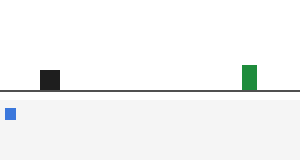

In [18]:
def play_viz(brain, max_frames=600):
    dino_x, y, vy = 40, 0.0, 0.0
    speed, obst, frames, cleared = 8, [250], [], 0
    layers = [(depth == 0), (depth >= 1) & (depth < 99), np.isin(np.arange(len(ids)), out_i)]
    sizes = [max(l.sum(), 1) for l in layers]
    for f in range(max_frames):
        ahead = [o for o in obst if o + 15 > dino_x]
        dist = (min(ahead) - dino_x) if ahead else 999
        rec = run_trace(brain, dist)
        act = [rec[:, l].any(0).sum() / s for l, s in zip(layers, sizes)]  # fraction that fired
        if y == 0 and rec[:, out_i].any(): vy = 12.0
        y = max(0.0, y + vy); vy -= 0.9
        if y == 0: vy = 0
        new = [o - speed for o in obst]
        cleared += sum(o <= -20 for o in new)
        obst = [o for o in new if o > -20]
        if max(obst) < 300: obst.append(max(obst) + random.randint(260, 400))
        dead = any(dino_x < o + 15 and dino_x + 20 > o and y < 25 for o in obst)

        game = np.full((100, 300, 3), 255, np.uint8); game[90:92] = 80
        yy = int(90 - 20 - y); game[max(yy, 0):yy + 20, dino_x:dino_x + 20] = (30, 30, 30)
        for o in obst:
            if 0 <= o < 285: game[65:90, int(o):int(o) + 15] = (30, 140, 60)
        panel = np.full((60, 300, 3), 245, np.uint8)
        for k, (a, col) in enumerate(zip(act, [(60,120,220), (150,150,150), (220,60,60)])):
            panel[8 + k*18: 8 + k*18 + 12, 5: 5 + int(290 * min(a * 4, 1))] = col  # ×4 so small fractions show
        frames.append(np.vstack([game, panel]))
        if dead: break
    return cleared, frames

frames = []
c, frames = play_viz(FlyBrain(g=g, ext=ext))
print("cleared:", c)
imageio.mimsave("fly_dino_viz.gif", frames[::2], duration=0.05)
display(Image("fly_dino_viz.gif"))